# Estimation fit: model vs data moments

Load estimated parameters from a completed CE run, solve + simulate at those values, and compare simulated moments against empirical targets from `moments_data.csv`.

Set `RESULTS_DIR` below to point at a finished estimation run (contains `theta_best.json`, `summary.json`, `fit_table.csv`, `convergence.csv`).

In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import json, os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# ── Gadi mount paths ──
GADI_RESULTS = os.path.expanduser('~/gadi/g/data/tp66/results/durables2_0/estimation')
GADI_SCRATCH = os.path.expanduser('~/gadi/scratch/tp66/as3442/durables_est')

def _scan_dir(root, label):
    """Scan for runs with summary.json (results) or state.pkl (scratch)."""
    if not os.path.isdir(root):
        return
    for spec in sorted(os.listdir(root)):
        spec_dir = os.path.join(root, spec)
        if not os.path.isdir(spec_dir):
            continue
        for item in sorted(os.listdir(spec_dir)):
            p = os.path.join(spec_dir, item)
            if os.path.isfile(os.path.join(p, 'summary.json')):
                print(f'  [{label}] {spec}/{item}')
            elif os.path.isfile(os.path.join(p, 'state.pkl')):
                print(f'  [{label}*] {spec}/{item}  (checkpoint only)')
            elif os.path.isdir(p):
                for sub in sorted(os.listdir(p)):
                    sp = os.path.join(p, sub)
                    if os.path.isfile(os.path.join(sp, 'summary.json')):
                        print(f'  [{label}] {spec}/{item}/{sub}')
                    elif os.path.isfile(os.path.join(sp, 'state.pkl')):
                        print(f'  [{label}*] {spec}/{item}/{sub}  (checkpoint only)')

print('Available runs (* = checkpoint only, no final results):')
_scan_dir(GADI_RESULTS, 'results')
_scan_dir(GADI_SCRATCH, 'scratch')

# ── Select a run ──
# Option A: point at a completed results dir (has summary.json)
# RESULTS_DIR = os.path.join(GADI_RESULTS, 'selfgen_large_egm', 'est_20260328_001535')

# Option B: point at a scratch checkpoint (has state.pkl, from a running or OOMed job)
RESULTS_DIR = os.path.join(GADI_SCRATCH, 'baseline_large_egm', 'est_20260328_012554')

# Mod directory (relative to repo root)
MOD_DIR = 'examples/durables2_0/mod/separable'

# Solver settings for re-simulation
GRID = 300
N_SIM = 10_000
CALIB_OVERRIDES = {'t0': 20}
SETTING_OVERRIDES = {'n_a': GRID, 'n_h': GRID, 'n_w': GRID}

print(f'\nResults: {RESULTS_DIR}')
print(f'Mod:     {MOD_DIR}')

## 1. Load estimation results

In [ ]:
# Load from summary.json (completed run) or state.pkl (checkpoint)
summary_path = os.path.join(RESULTS_DIR, 'summary.json')
state_path = os.path.join(RESULTS_DIR, 'state.pkl')

if os.path.exists(summary_path):
    # Completed run
    with open(summary_path) as f:
        summary = json.load(f)
    theta_best = summary['theta_best']
    theta_mean = summary.get('theta_mean', theta_best)
    theta_se = summary.get('theta_se', {})
    source = 'summary.json'

elif os.path.exists(state_path):
    # Checkpoint from running/OOMed job
    with open(state_path, 'rb') as f:
        state = pickle.load(f)
    theta_best = state['best_theta']
    theta_mean = state.get('means', theta_best)
    # Compute SE from covariance if available
    theta_se = {}
    if 'cov' in state:
        cov = np.asarray(state['cov'])
        names = sorted(theta_best.keys())
        se = np.sqrt(np.diag(cov))
        theta_se = {names[i]: float(se[i]) for i in range(len(names))}
    summary = {
        'objective': state['best_loss'],
        'converged': None,  # unknown from checkpoint
        'n_iter': state.get('it', -1) + 1,
    }
    source = f'state.pkl (iter {summary["n_iter"]})'

else:
    raise FileNotFoundError(
        f'No summary.json or state.pkl in {RESULTS_DIR}')

# Display
print(f'Source:    {source}')
print(f"Loss:      {summary['objective']:.6f}")
print(f"Converged: {summary['converged']} ({summary['n_iter']} iters)")
print()
print(f"{'param':12s} {'best':>10s} {'mean':>10s} {'SE':>10s}")
print('-' * 44)
for p in sorted(theta_best):
    se = theta_se.get(p, float('nan'))
    mn = theta_mean.get(p, float('nan')) if isinstance(theta_mean, dict) else float('nan')
    print(f"{p:12s} {theta_best[p]:10.4f} {mn:10.4f} {se:10.6f}")

## 2. Convergence

In [ ]:
# Convergence plot — from convergence.csv (completed run) or skip (checkpoint)
conv_path = os.path.join(RESULTS_DIR, 'convergence.csv')
if os.path.exists(conv_path):
    conv = pd.read_csv(conv_path)
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(conv['iter'], conv['best_loss'], 'o-', label='Best loss', markersize=4)
    ax.plot(conv['iter'], conv['elite_mean_loss'], 's--', label='Elite mean loss',
            markersize=4, alpha=0.7)
    ax.set_xlabel('CE iteration')
    ax.set_ylabel('SMM loss')
    ax.set_yscale('log')
    ax.legend()
    ax.set_title('Cross-entropy convergence')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print(f'No convergence.csv (loading from checkpoint). '
          f'Loss at iter {summary["n_iter"]}: {summary["objective"]:.6f}')

## 3. Solve at estimated parameters and simulate

In [17]:
from examples.durables2_0.solve import solve
from examples.durables2_0.horses.simulate import simulate_lifecycle

# Merge estimated params into calibration overrides
calib = {**CALIB_OVERRIDES, **theta_best}
print(f'Solving at theta_best: {theta_best}')

nest, grids = solve(
    MOD_DIR,
    calib_overrides=calib,
    setting_overrides=SETTING_OVERRIDES,
    verbose='summary',
)

sim_data = simulate_lifecycle(nest, grids, N=N_SIM, seed=99)
print(f'Simulation: {N_SIM} agents, {sim_data["c"].shape[0]} periods')

Solving at theta_best: {'alpha': 0.8030714315613761, 'beta': 0.9282766283727257, 'gamma_c': 5.321270015574636, 'gamma_h': 4.547366539484947, 'tau': 0.032602563493035884}


FileNotFoundError: [Errno 2] No such file or directory: 'examples/durables2_0/mod/separable/calibration.yaml'

## 4. Compute model moments and load data moments

In [ ]:
from pathlib import Path
from kikku.run.estimate import load_estimation_spec
from kikku.run.moments import make_moment_fn

# Load estimation spec (to get moment_spec and data_moments from CSV)
spec_path = os.path.join(MOD_DIR, 'estimation', 'baseline.yaml')
spec = load_estimation_spec(spec_path)
moment_spec = spec['moment_spec']
data_moments = spec['data_moments']

# Compute model moments from simulation
moment_fn = make_moment_fn(moment_spec)
sim_moments = moment_fn(sim_data)

# De-normalisation: model units * (1/normalisation) = AUD
stage0 = nest['periods'][0]['stages']['keeper_cons']
denorm = 1.0 / float(stage0.settings['normalisation'])
print(f'De-normalisation factor: {denorm:.0f}')

# Apply to means and SDs (not correlations/autocorrelations)
sim_moments_denorm = {}
for k, v in sim_moments.items():
    if any(k.startswith(p) for p in ('mean_', 'sd_', 'av_',
                                       'cond_discrete_0_mean_', 'cond_discrete_1_mean_',
                                       'cond_discrete_0_sd_', 'cond_discrete_1_sd_')):
        sim_moments_denorm[k] = v * denorm
    else:
        sim_moments_denorm[k] = v

# Build target keys from YAML targets section (not get_moment_names which has T=10 bug)
targets = moment_spec.get('targets') or []
target_prefixes = set(t['key'] for t in targets)
# Keep data moments that match target prefixes
target_keys = sorted(
    k for k in data_moments
    if any(k.startswith(p + '__') or k == p for p in target_prefixes)
    and k in sim_moments_denorm
)
print(f'Data moments:  {len(data_moments)} keys (CSV)')
print(f'Sim moments:   {len(sim_moments)} keys (model)')
print(f'Target keys:   {len(target_keys)} (matched)')

De-normalisation factor: 100000
Data moments:  1069 keys (CSV)
Sim moments:   234 keys (model)
Target keys:   70 (matched)


## 5. Fit table

In [ ]:
# Build fit table: data vs model (de-normalised) for each targeted moment
import re

# Debug: check key overlap
data_keys = set(data_moments.keys())
sim_keys = set(sim_moments_denorm.keys())
overlap = data_keys & sim_keys
print(f'Data keys: {len(data_keys)}, Sim keys: {len(sim_keys)}, Overlap: {len(overlap)}')
if not overlap:
    print('\nNO OVERLAP! Showing sample keys:')
    print(f'  Data (first 5): {sorted(data_keys)[:5]}')
    print(f'  Sim  (first 5): {sorted(sim_keys)[:5]}')

rows = []
for k in target_keys:
    d = data_moments[k]
    s = sim_moments_denorm.get(k, float('nan'))
    if np.isnan(d) or np.isnan(s):
        continue
    resid = s - d
    denom = d**2 if abs(d) >= 1.0 else 1.0
    contrib = resid**2 / max(denom, 1e-20)
    rows.append({'moment': k, 'data': d, 'model': s,
                 'residual': resid, 'contribution': contrib})

if not rows:
    print('\nNo matched moments with valid data+model values.')
else:
    fit_df = pd.DataFrame(rows)
    fit_df['pct_dev'] = 100 * fit_df['residual'] / fit_df['data'].where(fit_df['data'].abs() >= 1, 1.0)
    fit_df = fit_df.sort_values('contribution', ascending=False)

    total_loss = fit_df['contribution'].sum()
    fit_df['share'] = 100 * fit_df['contribution'] / total_loss

    print(f'\nTotal SMM loss (de-normalised): {total_loss:.4f}')
    print()
    print(fit_df[['moment', 'data', 'model', 'pct_dev', 'share']].to_string(
        index=False, float_format='%.3f'))

Data keys: 1069, Sim keys: 234, Overlap: 70

Total SMM loss (de-normalised): 97.5505

                      moment       data      model  pct_dev  share
    av_fin_assets_14_0__age3   2297.980  19371.371  742.974 56.587
    sd_fin_assets_14_0__age3   6344.785  23768.582  274.616  7.731
autocorr_consumption_0__age4     -0.979      0.933  191.239  3.749
autocorr_wealth_real_0__age4     -0.632      0.946  157.774  2.552
autocorr_wealth_real_0__age2     -0.484      0.917  140.091  2.012
  av_consumption2_14_0__age4  26316.430  60391.224  129.481  1.719
autocorr_consumption_0__age2     -0.290      0.924  121.460  1.512
autocorr_consumption_0__age3     -0.233      0.930  116.287  1.386
  av_consumption2_14_0__age6  32770.594  68686.193  109.597  1.231
  corr_cons_realw_14_0__age8     -0.317      0.770  108.693  1.211
    sd_fin_assets_14_0__age4  15042.558  30422.729  102.244  1.072
  corr_cons_realw_14_0__age3     -0.130      0.883  101.287  1.052
  corr_cons_realw_14_0__age6     -0.123    

## 6. Model vs data by age group

Targeted moments plotted by age group: means, standard deviations, correlations, autocorrelations.

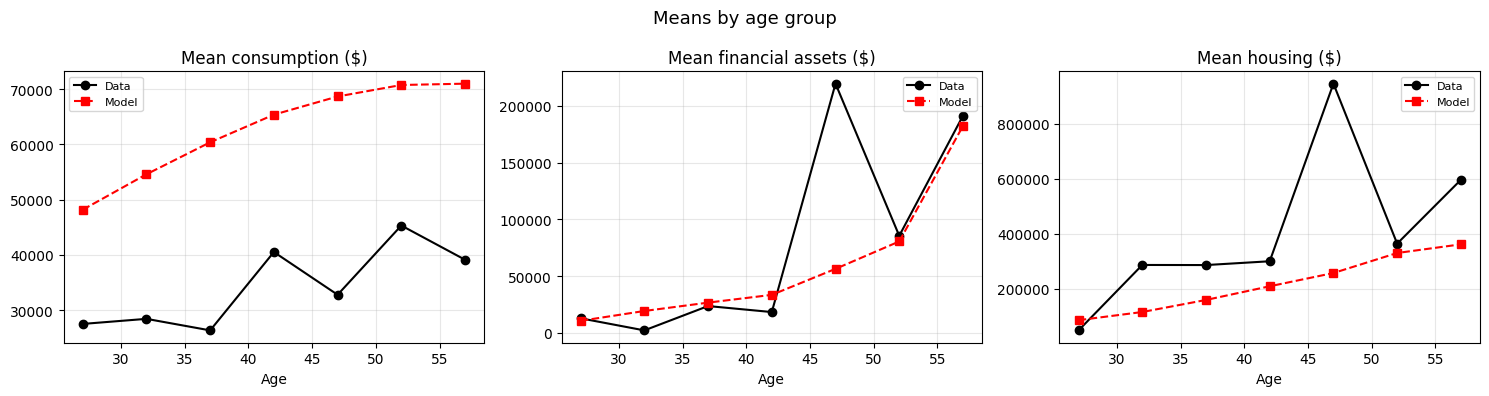

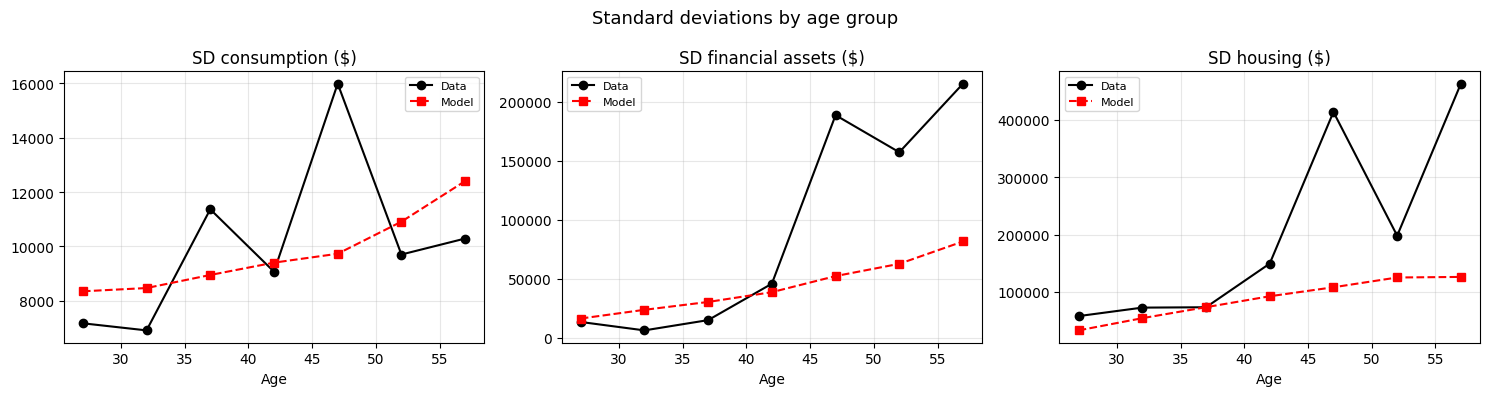

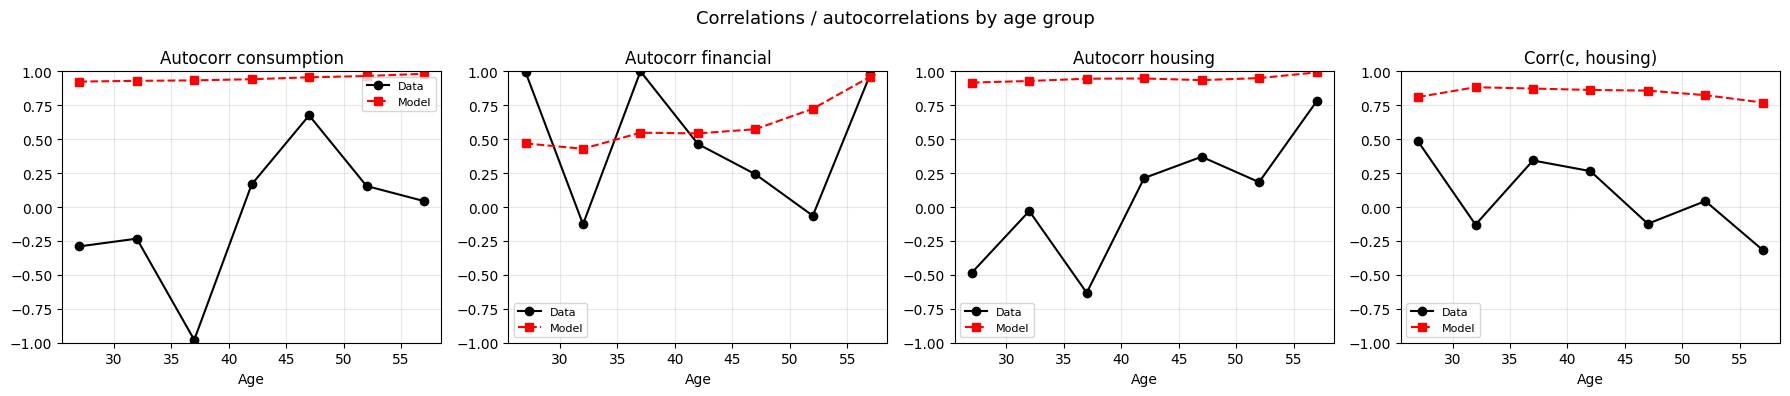

In [ ]:
# Parse moment keys into (base_name, age_group) and group by base_name
def parse_key(k):
    m = re.match(r'^(.+)__age(\d+)$', k)
    if m:
        return m.group(1), int(m.group(2))
    return k, None

# Group ALL targeted moments by base name — plot data even if model is NaN
from collections import defaultdict
moment_groups = defaultdict(list)
for k in target_keys:
    base, ag = parse_key(k)
    d = data_moments.get(k, float('nan'))
    s = sim_moments_denorm.get(k, float('nan'))
    if not np.isnan(d):
        moment_groups[base].append((ag, d, s))

# Age group midpoints for x-axis
age_mid = {1: 22, 2: 27, 3: 32, 4: 37, 5: 42, 6: 47, 7: 52, 8: 57, 9: 62}

LABELS = {
    'av_consumption2_14_0': 'Mean consumption ($)',
    'av_wealth_real_14_0': 'Mean housing ($)',
    'av_fin_assets_14_0': 'Mean financial assets ($)',
    'sd_consumption2_14_0': 'SD consumption ($)',
    'sd_wealth_real_14_0': 'SD housing ($)',
    'sd_fin_assets_14_0': 'SD financial assets ($)',
    'corr_cons_realw_14_0': 'Corr(c, housing)',
    'autocorr_wealth_real_0': 'Autocorr housing',
    'autocorr_wealth_fin_0': 'Autocorr financial',
    'autocorr_consumption_0': 'Autocorr consumption',
    'mean_c': 'Mean consumption ($)',
    'mean_a': 'Mean financial assets ($)',
    'mean_h': 'Mean housing ($)',
    'sd_c': 'SD consumption ($)',
    'sd_a': 'SD financial assets ($)',
    'sd_h': 'SD housing ($)',
    'corr_c_h': 'Corr(c, housing)',
    'corr_c_a': 'Corr(c, assets)',
    'corr_a_h': 'Corr(assets, housing)',
    'autocorr_c': 'Autocorr consumption',
    'autocorr_a': 'Autocorr financial',
    'autocorr_h': 'Autocorr housing',
}

def _plot_group(bases, title):
    n = len(bases)
    if not n:
        return
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    for i, base in enumerate(sorted(bases)):
        ax = axes[0, i]
        pts = sorted(moment_groups[base])
        ages = [age_mid.get(ag, ag) for ag, _, _ in pts]
        data_vals = [d for _, d, _ in pts]
        model_vals = [s for _, _, s in pts]
        ax.plot(ages, data_vals, 'ko-', label='Data', markersize=6)
        # Only plot model if at least one non-NaN value
        valid_model = [s for s in model_vals if not np.isnan(s)]
        if valid_model:
            ax.plot(ages, model_vals, 'rs--', label='Model', markersize=6)
        ax.set_xlabel('Age')
        ax.set_title(LABELS.get(base, base))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

# --- Means ---
_plot_group([b for b in moment_groups if b.startswith(('av_', 'mean_'))],
            'Means by age group')

# --- Standard deviations ---
_plot_group([b for b in moment_groups if b.startswith('sd_')],
            'Standard deviations by age group')

# --- Correlations and autocorrelations ---
corr_bases = [b for b in moment_groups if not b.startswith(('av_', 'mean_', 'sd_'))]
if corr_bases:
    n = len(corr_bases)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), squeeze=False)
    for i, base in enumerate(sorted(corr_bases)):
        ax = axes[0, i]
        pts = sorted(moment_groups[base])
        ages = [age_mid.get(ag, ag) for ag, _, _ in pts]
        data_vals = [d for _, d, _ in pts]
        model_vals = [s for _, _, s in pts]
        ax.plot(ages, data_vals, 'ko-', label='Data', markersize=6)
        valid_model = [s for s in model_vals if not np.isnan(s)]
        if valid_model:
            ax.plot(ages, model_vals, 'rs--', label='Model', markersize=6)
        ax.set_xlabel('Age')
        ax.set_title(LABELS.get(base, base))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-1, 1)
    fig.suptitle('Correlations / autocorrelations by age group', fontsize=13)
    fig.tight_layout()
    plt.show()

## 7. Lifecycle profiles at estimated parameters

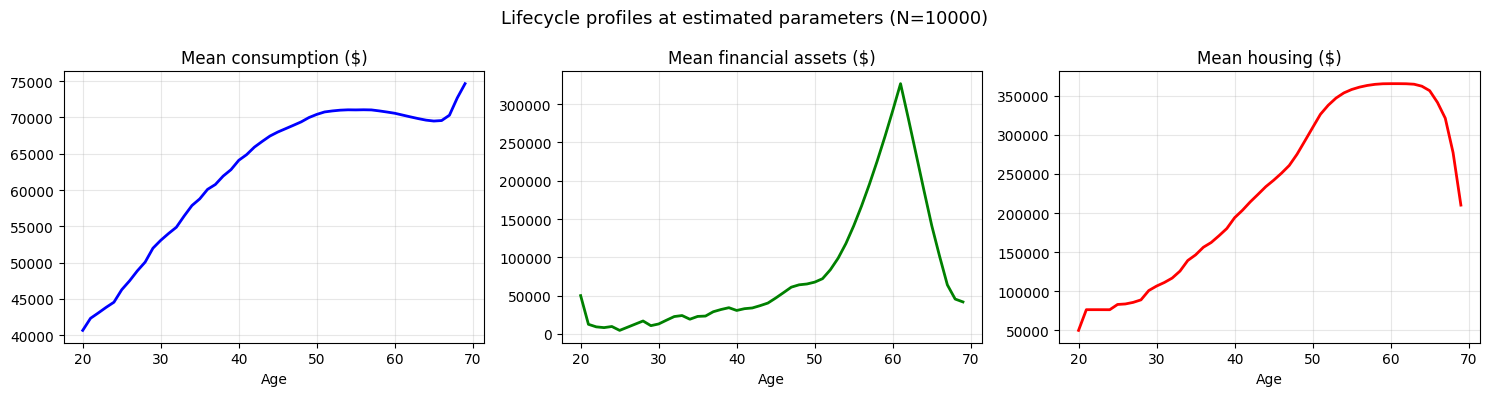

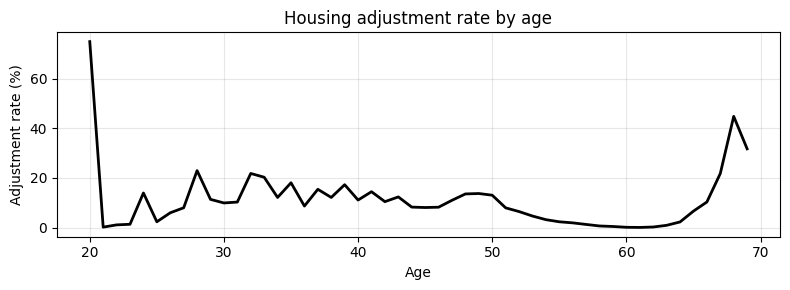

In [ ]:
# Lifecycle: mean consumption, assets, housing by age (in AUD)
t0 = int(stage0.calibration['t0'])
T = int(stage0.settings['T'])

ages = np.arange(t0, T)
mean_c = np.nanmean(sim_data['c'][t0:T], axis=1) * denorm
mean_a = np.nanmean(sim_data['a'][t0:T], axis=1) * denorm
mean_h = np.nanmean(sim_data['h'][t0:T], axis=1) * denorm

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ages, mean_c, 'b-', linewidth=2)
axes[0].set_title('Mean consumption ($)')
axes[0].set_xlabel('Age')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ages, mean_a, 'g-', linewidth=2)
axes[1].set_title('Mean financial assets ($)')
axes[1].set_xlabel('Age')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ages, mean_h, 'r-', linewidth=2)
axes[2].set_title('Mean housing ($)')
axes[2].set_xlabel('Age')
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Lifecycle profiles at estimated parameters (N={N_SIM})', fontsize=13)
fig.tight_layout()
plt.show()

# Adjustment rate by age
if 'discrete' in sim_data:
    d = sim_data['discrete'][t0:T]
    adj_rate = np.nanmean(d, axis=1)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(ages, adj_rate * 100, 'k-', linewidth=2)
    ax.set_xlabel('Age')
    ax.set_ylabel('Adjustment rate (%)')
    ax.set_title('Housing adjustment rate by age')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

## 8. Loss decomposition

Bar chart showing which moments contribute most to the total SMM loss.

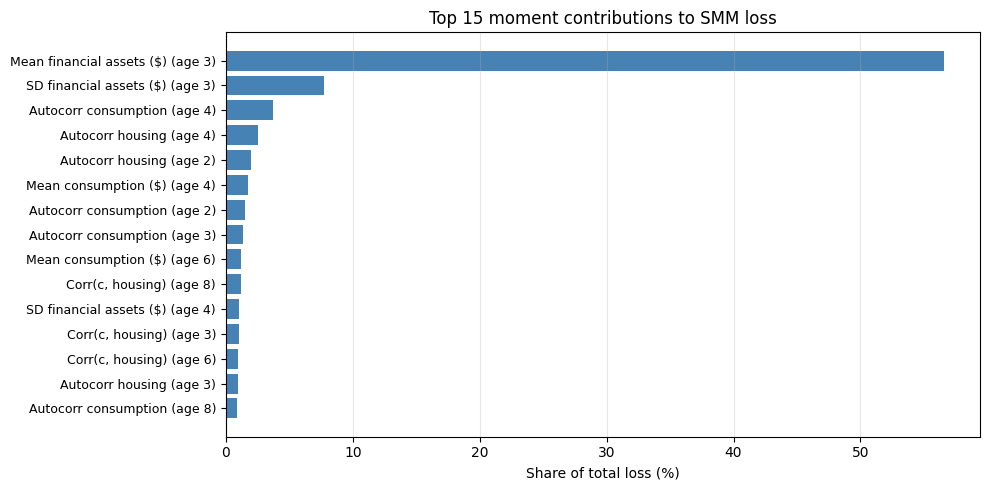

In [ ]:
# Top contributors to loss
top = fit_df.head(15).copy()
top['label'] = top['moment'].apply(
    lambda k: LABELS.get(parse_key(k)[0], parse_key(k)[0]) + f' (age {parse_key(k)[1]})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top)), top['share'].values, color='steelblue')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['label'].values, fontsize=9)
ax.set_xlabel('Share of total loss (%)')
ax.set_title('Top 15 moment contributions to SMM loss')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
plt.show()